# Time Series — Per-Plot Phenology at Scale

Extracts per-plot phenology metrics from the assembled weekly NDVI data (35,980 rows: 3,598 plots × ~10 years).

**Metrics computed:**
- `ndvi_trend_slope`: OLS slope of mean_anomaly ~ year per plot (is terroir signal intensifying or relaxing?)
- `ndvi_peak_week_mean`: average week of NDVI peak across years
- `ndvi_peak_week_std`: year-to-year variation in peak timing
- `ndvi_season_amplitude`: mean(max − min NDVI per year) per plot
- `ndvi_season_amplitude_std`: year-to-year variation in amplitude

These phenology features can be joined back to the main df for use as additional terroir indicators in the ensemble.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_pickle('../data/df.pkl')
print('Shape:', df.shape)

# NDVI columns available
ndvi_mean_cols = sorted([c for c in df.columns if c.startswith('ndvi_smooth_mean_')])
anomaly_cols   = sorted([c for c in df.columns if c.startswith('ndvi_anomaly_')])
print('NDVI mean weeks:', [c.split('_')[-1] for c in ndvi_mean_cols])
print('Anomaly weeks:  ', [c.split('_')[-1] for c in anomaly_cols])

Shape: (35980, 367)
NDVI mean weeks: ['13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45']
Anomaly weeks:   ['36', '37', '38', '39', '40', '41', '42', '43']


## Trend Slope: is a plot's terroir signal strengthening over time?

For each plot, fit OLS on mean_anomaly (averaged across harvest weeks 36–43) ~ year.  
Positive slope → plot is increasingly above-average. Negative → declining relative to vineyard.

In [3]:
# Mean anomaly per plot × year (scalar per row)
df['mean_anomaly'] = df[anomaly_cols].mean(axis=1)

def plot_trend_slope(grp):
    years = grp['year'].values
    vals  = grp['mean_anomaly'].values
    if len(years) < 3 or np.isnan(vals).all():
        return np.nan
    mask = ~np.isnan(vals)
    if mask.sum() < 3:
        return np.nan
    slope, _, _, _, _ = stats.linregress(years[mask], vals[mask])
    return slope

trend_slopes = df.groupby('plot_id').apply(plot_trend_slope).rename('ndvi_trend_slope')
print('Trend slopes — n:', len(trend_slopes), '| mean:', trend_slopes.mean().round(5),
      '| std:', trend_slopes.std().round(5))

Trend slopes — n: 3598 | mean: -0.0 | std: 0.01289


/tmp/ipykernel_592087/816033141.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_slopes = df.groupby('plot_id').apply(plot_trend_slope).rename('ndvi_trend_slope')


## Seasonal Amplitude — how vigorously does each plot cycle?

Using the full weekly NDVI profile (weeks 13–45), compute peak and trough per plot × year.

In [4]:
# Seasonal amplitude per plot × year
df['ndvi_profile_max'] = df[ndvi_mean_cols].max(axis=1)
df['ndvi_profile_min'] = df[ndvi_mean_cols].min(axis=1)
df['ndvi_amplitude']   = df['ndvi_profile_max'] - df['ndvi_profile_min']

# Peak week: which column index (week number) has the maximum NDVI
week_numbers = np.array([int(c.split('_')[-1]) for c in ndvi_mean_cols])
peak_idx = df[ndvi_mean_cols].values.argmax(axis=1)  # column index of max
df['ndvi_peak_week'] = week_numbers[peak_idx]

# Aggregate per plot
pheno = df.groupby('plot_id').agg(
    ndvi_season_amplitude_mean=('ndvi_amplitude', 'mean'),
    ndvi_season_amplitude_std =('ndvi_amplitude', 'std'),
    ndvi_peak_week_mean       =('ndvi_peak_week', 'mean'),
    ndvi_peak_week_std        =('ndvi_peak_week', 'std'),
).reset_index()

print(pheno.describe().round(3))

        plot_id  ndvi_season_amplitude_mean  ndvi_season_amplitude_std  \
count  3598.000                    3598.000                   3598.000   
mean   1798.500                       0.243                      0.077   
std    1038.797                       0.072                      0.028   
min       0.000                       0.074                      0.013   
25%     899.250                       0.190                      0.058   
50%    1798.500                       0.235                      0.071   
75%    2697.750                       0.289                      0.092   
max    3597.000                       0.443                      0.181   

       ndvi_peak_week_mean  ndvi_peak_week_std  
count             3598.000            3598.000  
mean                29.945               5.133  
std                  3.397               2.550  
min                 17.400               0.699  
25%                 27.800               3.367  
50%                 29.300             

In [5]:
# Combine all phenology metrics
pheno = pheno.merge(trend_slopes.reset_index(), on='plot_id')
print('Phenology table shape:', pheno.shape)
print(pheno.head())

Phenology table shape: (3598, 6)
   plot_id  ndvi_season_amplitude_mean  ndvi_season_amplitude_std  \
0        0                    0.155560                   0.051960   
1        1                    0.152676                   0.053116   
2        2                    0.150553                   0.048921   
3        3                    0.095070                   0.025145   
4        4                    0.123105                   0.022594   

   ndvi_peak_week_mean  ndvi_peak_week_std  ndvi_trend_slope  
0                 26.2           14.520484         -0.000891  
1                 29.4           15.027382          0.002191  
2                 26.2           14.740722          0.004071  
3                 26.8           14.234543          0.003079  
4                 28.9           13.295363         -0.000390  


## Do phenology metrics differ by cluster?

In [6]:
import os
from scipy.stats import kruskal

# Load cluster assignments if available
clustered_path = '../ML/df_clustered.pkl'
if not os.path.exists(clustered_path):
    clustered_path = 'df_clustered.pkl'

if os.path.exists(clustered_path):
    cluster_df = pd.read_pickle(clustered_path)[['plot_id', 'cluster']].drop_duplicates()
    pheno = pheno.merge(cluster_df, on='plot_id', how='left')
    has_clusters = True
    print('Cluster counts:', pheno['cluster'].value_counts().to_dict())
else:
    has_clusters = False
    print('df_clustered.pkl not found — run clustering.ipynb first')

Cluster counts: {1: 1733, 2: 934, 0: 931}


In [7]:
pheno_metrics = [
    'ndvi_trend_slope',
    'ndvi_season_amplitude_mean',
    'ndvi_peak_week_mean',
    'ndvi_peak_week_std',
]

if has_clusters:
    from scipy.stats import kruskal
    sorted_clusters = sorted(pheno['cluster'].dropna().unique())
    print('Kruskal-Wallis (phenology metrics vs cluster):')
    for metric in pheno_metrics:
        groups = [pheno[pheno['cluster'] == c][metric].dropna() for c in sorted_clusters]
        if all(len(g) > 1 for g in groups):
            h, p = kruskal(*groups)
            print(f'  {metric}: H={h:.2f}, p={p:.4f}')

Kruskal-Wallis (phenology metrics vs cluster):
  ndvi_trend_slope: H=1263.70, p=0.0000
  ndvi_season_amplitude_mean: H=128.10, p=0.0000
  ndvi_peak_week_mean: H=62.95, p=0.0000
  ndvi_peak_week_std: H=633.70, p=0.0000


## Visualization

In [ ]:
# Distribution of trend slopes
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

metric_labels = {
    'ndvi_trend_slope':          'Trend slope (anomaly/year)',
    'ndvi_season_amplitude_mean':'Season amplitude (mean NDVI range)',
    'ndvi_peak_week_mean':       'Mean peak week',
    'ndvi_peak_week_std':        'Peak week variability (std)',
}

cmap_k = plt.colormaps['viridis'].resampled(3)

for ax, metric in zip(axes.flat, pheno_metrics):
    if has_clusters:
        for c in sorted_clusters:
            vals = pheno[pheno['cluster'] == c][metric].dropna()
            counts, edges = np.histogram(vals, bins=40)
            ax.stairs(counts, edges, fill=True, alpha=0.5,
                      color=cmap_k(c / max(sorted_clusters)), label=f'Cluster {c}')
        ax.legend(fontsize=8)
    else:
        vals = pheno[metric].dropna()
        counts, edges = np.histogram(vals, bins=40)
        ax.stairs(counts, edges, fill=True, alpha=0.7, color='steelblue')

    ax.set_xlabel(metric_labels[metric])
    ax.set_ylabel('Plots')
    ax.set_title(metric_labels[metric])
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-Plot Phenology Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('../img/phenology_distributions.png', dpi=150)
plt.show()


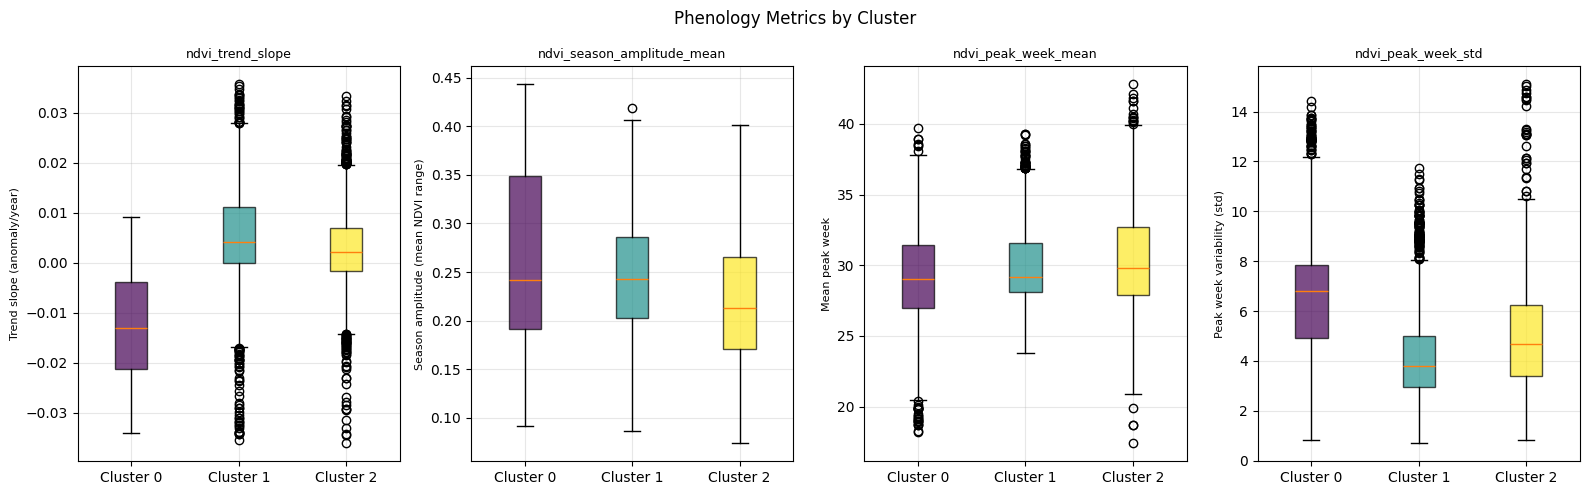

In [9]:
# Boxplots by cluster
if has_clusters:
    fig, axes = plt.subplots(1, len(pheno_metrics), figsize=(16, 5))

    for ax, metric in zip(axes, pheno_metrics):
        groups = [pheno[pheno['cluster'] == c][metric].dropna().values
                  for c in sorted_clusters]
        bp = ax.boxplot(groups, patch_artist=True,
                        tick_labels=[f'Cluster {c}' for c in sorted_clusters])
        for patch, c in zip(bp['boxes'], sorted_clusters):
            patch.set_facecolor(cmap_k(c / max(sorted_clusters)))
            patch.set_alpha(0.7)
        ax.set_title(metric, fontsize=9)
        ax.set_ylabel(metric_labels[metric], fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Phenology Metrics by Cluster', fontsize=12)
    plt.tight_layout()
    plt.savefig('../img/phenology_by_cluster.png', dpi=150)
    plt.show()

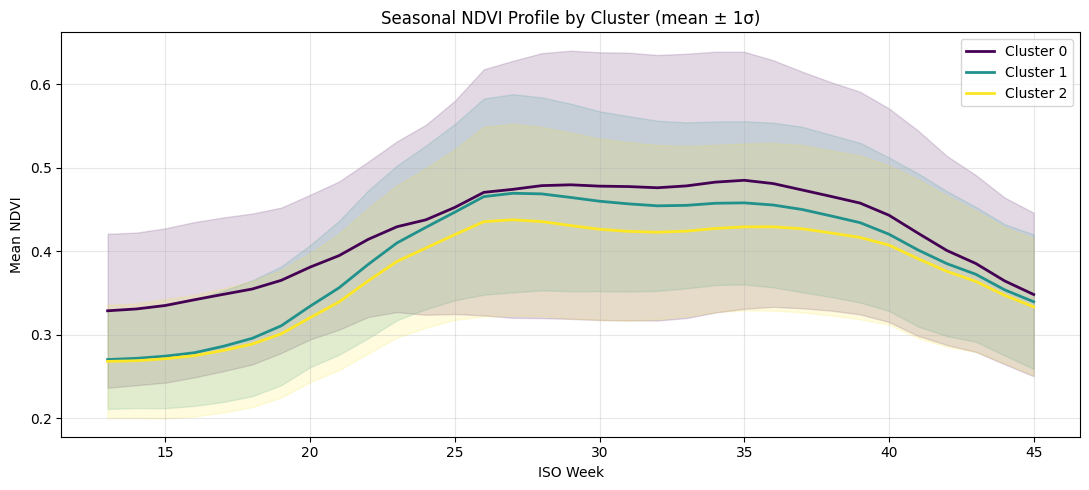

In [10]:
# Mean NDVI profile by cluster — seasonal fingerprint
profile_df = df.copy()
if has_clusters:
    cluster_col = pheno[['plot_id', 'cluster']]
    profile_df = profile_df.merge(cluster_col, on='plot_id', how='left')

    fig, ax = plt.subplots(figsize=(11, 5))
    for c in sorted_clusters:
        sub = profile_df[profile_df['cluster'] == c][ndvi_mean_cols]
        mean_profile = sub.mean()
        std_profile  = sub.std()
        ax.plot(week_numbers, mean_profile, label=f'Cluster {c}',
                color=cmap_k(c / max(sorted_clusters)), linewidth=2)
        ax.fill_between(
            week_numbers,
            mean_profile - std_profile,
            mean_profile + std_profile,
            alpha=0.15, color=cmap_k(c / max(sorted_clusters))
        )

    ax.set_xlabel('ISO Week')
    ax.set_ylabel('Mean NDVI')
    ax.set_title('Seasonal NDVI Profile by Cluster (mean ± 1σ)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../img/seasonal_profile_by_cluster.png', dpi=150)
    plt.show()
else:
    print('Need cluster assignments — run clustering.ipynb first')

## Save Phenology Features

Can be joined back to `df.pkl` on `plot_id` to augment the feature set for the ensemble or stability regression.

In [11]:
pheno_out = pheno[['plot_id'] + pheno_metrics + ['ndvi_season_amplitude_std']].copy()
pheno_out.to_pickle('../data/phenology_features.pkl')
print(f'Saved {len(pheno_out)} plot phenology features to data/phenology_features.pkl')
print(pheno_out.describe().round(4))

Saved 3598 plot phenology features to data/phenology_features.pkl
         plot_id  ndvi_trend_slope  ndvi_season_amplitude_mean  \
count  3598.0000         3598.0000                   3598.0000   
mean   1798.5000           -0.0000                      0.2431   
std    1038.7975            0.0129                      0.0724   
min       0.0000           -0.0361                      0.0739   
25%     899.2500           -0.0059                      0.1900   
50%    1798.5000            0.0011                      0.2347   
75%    2697.7500            0.0065                      0.2892   
max    3597.0000            0.0357                      0.4431   

       ndvi_peak_week_mean  ndvi_peak_week_std  ndvi_season_amplitude_std  
count            3598.0000           3598.0000                  3598.0000  
mean               29.9448              5.1334                     0.0773  
std                 3.3965              2.5496                     0.0280  
min                17.4000         